In [9]:
from pprint import pprint
# import m2aia as m2
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import stlearn as st

In [2]:
import subprocess
system = subprocess.check_output(["hostname", "-s"]).decode("utf-8").strip()
BASE_PATH_ = Path()
if "bun" in system:
    BASE_PATH_ = Path("/QRISdata/Q1851/Xiao/")
elif "imb-quan-gpu" in system:
    BASE_PATH_ = Path("/home/uqxtan9/Q1851/Xiao/")


BASE_PATH = BASE_PATH_ / "Working_project/MB"
DATA_PATH = BASE_PATH / "Xenium_Brain"
XENIUM_RAW_PATH = DATA_PATH / "Xenium_RAW"
MALDI_RAW_PATH = DATA_PATH / "MALDI_RAW/imzml_file"
PROCESSED = BASE_PATH / "PROCESSED"
PROCESSED.mkdir(exist_ok=True, parents=True)
OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
OUT_PATH.mkdir(exist_ok=True, parents=True)
QC_PATH = OUT_PATH / "QC"
QC_PATH.mkdir(exist_ok=True, parents=True)
CLS_PATH = OUT_PATH / "CLUSTERING"
CLS_PATH.mkdir(exist_ok=True, parents=True)

In [3]:
import cv2
def rotate_point(point, cx, cy, h, w, theta):
    # opencv calculates standard transformation matrix
    M = cv2.getRotationMatrix2D((cx, cy), theta, 1.0)
    # Grab  the rotation components of the matrix)
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    # compute the new bounding dimensions of the image
    nW = int((h * sin) + (w * cos))
    nH = int((h * cos) + (w * sin))
    # adjust the rotation matrix to take into account translation
    M[0, 2] += (nW / 2) - cx
    M[1, 2] += (nH / 2) - cy
    # Prepare the vector to be transformed
    v = [point[0],point[1],1]
    # Perform the actual rotation and return the image
    calculated = np.dot(M,v)
    return calculated[0],calculated[1]

def rotate(img, x_coor, y_coor, theta):
    # (heigth, width) = np.array(img).shape[:2]
    (width, heigth) = np.array(img).shape[:2]
    (cx, cy) = (width // 2, heigth // 2)
    x_new_ls = []
    y_new_ls = []
    for x,y in zip(x_coor, y_coor):
        x_new,y_new = rotate_point([x,y], cx, cy, heigth, width, theta)
        x_new_ls.append(x_new)
        y_new_ls.append(y_new)
    return x_new_ls, y_new_ls

In [4]:
Sample_ls = ["Ctrl_1", "Ctrl_2", "Treated_1", "Treated_2"]
Sample_ls_ = ["control 1", "control 2", "treated 1", "treated 2"]

In [56]:
maldi_mask_dict = {}
maldi_cor = {}
for sample, sample_ in zip(Sample_ls, Sample_ls_):
    # actually load the file
    I = m2.ImzMLReader(str(MALDI_RAW_PATH / f"dhb-tissue region {sample_}.imzML"), 
                    normalization=m2.m2NormalizationRMS,
                    pooling=m2.m2PoolingMaximum
                    )
    mask = I.GetMaskArray()[0]
    maldi_mask_dict[sample] = mask
    maldi_cor[sample] = np.argwhere(mask)

[272.034] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region control 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 310x356x1
	[num spectra]: 84027
	[spec. type]: ProcessedCentroid
	[mass range]: 160.713978 to 2999.027599 with #1500 measurements
	[normalization]: RMS
[277.765] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region control 2.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 255x427x1
	[num spectra]: 71722
	[spec. type]: ProcessedCentroid
	[mass range]: 160.855288 to 2999.028214 with #1500 measurements
	[normalization]: RMS
[286.802] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 325x507x1
	[num spectra]: 116598
	[spec. type]: ProcessedCentroid
	[mass range]: 160.809851 to 2999.02

In [5]:
samples = {}
for i, name in enumerate(Sample_ls):
    print(f"Processing {name} ({i+1}/{len(Sample_ls)})")
    adata= sc.read(PROCESSED / f"{name}_processed_marker_label.h5ad")
    samples[name] = adata

Processing Ctrl_1 (1/4)
Processing Ctrl_2 (2/4)
Processing Treated_1 (3/4)
Processing Treated_2 (4/4)


In [6]:
adata.obs

,imagecol,imagerow,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_10_genes,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_150_genes,n_counts,total_counts_mt,pct_counts_mt,leiden,cell_type
aaabbpnk-1,2003.667114,835.989319,16,2.833213,30.0,3.433987,80.000000,100.000000,100.0,100.0,30.0,0.0,0.0,5,Oligodendrocyte
aaabfigi-1,2294.924805,835.761047,24,3.218876,45.0,3.828641,68.888889,91.111111,100.0,100.0,45.0,0.0,0.0,5,Astrocyte
aaabkjjc-1,2106.097412,841.447998,29,3.401197,107.0,4.682131,76.635514,91.588785,100.0,100.0,107.0,0.0,0.0,5,Astrocyte
aaabnbff-1,2347.399170,837.882935,16,2.833213,36.0,3.610918,83.333333,100.000000,100.0,100.0,36.0,0.0,0.0,5,Astrocyte
aaacdokn-1,1971.025391,842.312073,30,3.433987,108.0,4.691348,68.518519,90.740741,100.0,100.0,108.0,0.0,0.0,5,Astrocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oiokikgd-1,8457.062500,2731.571777,41,3.737670,94.0,4.553877,60.638298,77.659574,100.0,100.0,94.0,0.0,0.0,4,Cancer cells
oiokkpea-1,8455.866211,2703.900146,43,3.784190,114.0,4.744932,54.385965,77.192982,100.0,100.0,114.0,0.0,0.0,1,Cancer cells
oioklcii-1,8456.054688,2716.914795,13,2.639057,20.0,3.044523,85.000000,100.000000,100.0,100.0,20.0,0.0,0.0,3,Cancer cells
oiokpaph-1,8457.458984,2695.205322,17,2.890372,35.0,3.583519,80.000000,100.000000,100.0,100.0,35.0,0.0,0.0,3,Cancer cells


Processing Ctrl_1


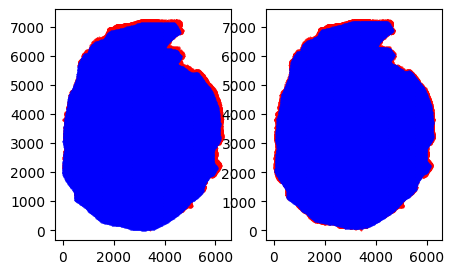

Processing Ctrl_2


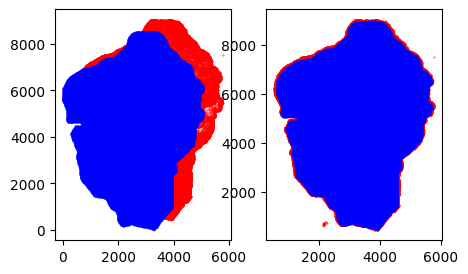

Processing Treated_1


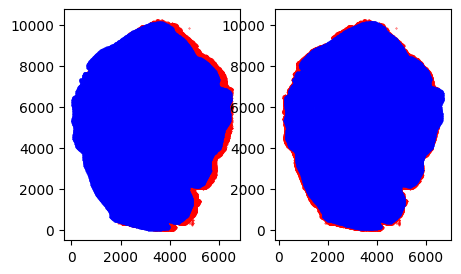

Processing Treated_2


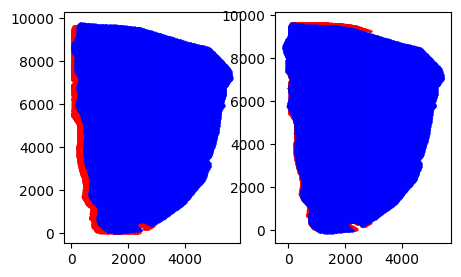

In [ ]:
for name, adata in samples.items():
    print(f"Processing {name}")
    fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(5, 3))
    xenium_x = adata.obs["imagerow"]
    xenium_y = adata.obs["imagecol"]
    axes[0].scatter(xenium_x, xenium_y, color="red",s=0.1)
    maldi_x = maldi_cor[name][:,0]
    maldi_y = maldi_cor[name][:,1]
    maldi_x1, maldi_y1 = rotate(maldi_mask_dict[name], maldi_x, maldi_y, 90)
    maldi_x2 = [i*20 for i in maldi_x1]
    maldi_y2 = [i*20 for i in maldi_y1]
    axes[0].scatter(maldi_x2, maldi_y2, color="blue",s=0.1)
    
    axes[1].scatter(xenium_x, xenium_y, color="red",s=0.1)
    df = pd.read_csv(PROCESSED/ f"{name}_mapped_coordinates.csv")
    maldi_x3, maldi_y3 = df["aligned_x"], df["aligned_y"]
    axes[1].scatter(maldi_x3, maldi_y3, color="blue",s=0.1)
    plt.show()
